##Laboratory work 6. Object Detection Overview

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
image_path = ("/content/drive/MyDrive/CV-Spring-2026/lab6/images/original_image.png")

In [41]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import numpy as np
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights
)

#Task 1. Image and bounding box concept

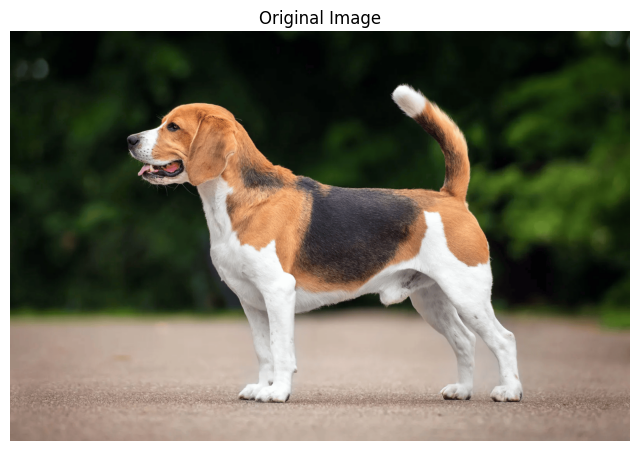

In [42]:
#load image

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [43]:
#define manual binding box
x = 200
y = 120
width = 1150
height = 780

print("Manual Bounding Box (x, y, width, height):")
print((x, y, width, height))

Manual Bounding Box (x, y, width, height):
(200, 120, 1150, 780)


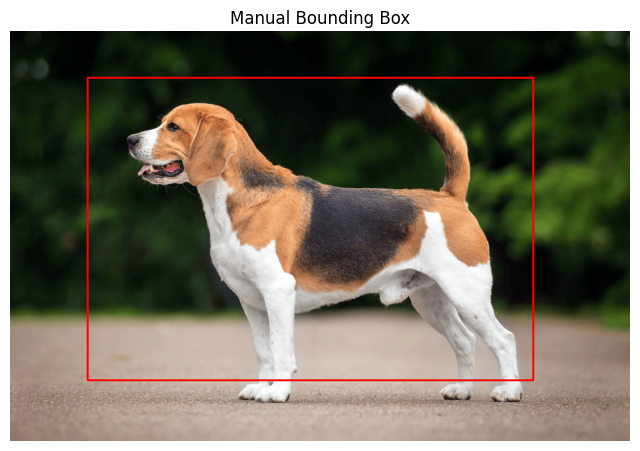

In [44]:
#draw manual bounding box
image_manual = image.copy()

cv2.rectangle(
    image_manual,
    (x, y),
    (x + width, y + height),
    (255, 0, 0),
    4
)

plt.figure(figsize=(8,6))
plt.imshow(image_manual)
plt.title("Manual Bounding Box")
plt.axis("off")
plt.show()

#Task 2. Object detection using a pretrained detector

In [45]:
#load faster r-cnn model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

categories = weights.meta["categories"]

In [46]:
#prepare image tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

image_tensor = transform(image)

In [47]:
#run detection
with torch.no_grad():
    predictions = model([image_tensor])

In [48]:
#extract detection results
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

print("Total detected objects:", len(boxes))

Total detected objects: 2


In [49]:
#filter detections by confidence (0.5)
threshold = 0.5

filtered_boxes = []
filtered_labels = []
filtered_scores = []

for i in range(len(scores)):
    if scores[i] > threshold:
        filtered_boxes.append(boxes[i])
        filtered_labels.append(labels[i])
        filtered_scores.append(scores[i])

print("Objects above threshold:", len(filtered_boxes))

Objects above threshold: 1


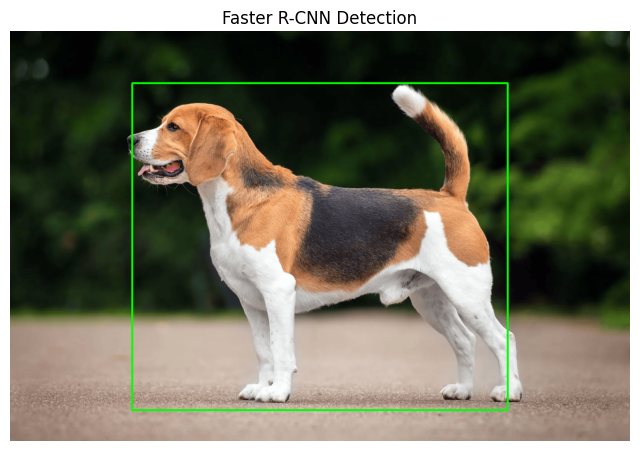

In [50]:
#display detected bounding boxes
image_detected = image.copy()

for i in range(len(filtered_boxes)):
    box = filtered_boxes[i]

    x1 = int(box[0].item())
    y1 = int(box[1].item())
    x2 = int(box[2].item())
    y2 = int(box[3].item())

    cv2.rectangle(
        image_detected,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        4
    )

plt.figure(figsize=(8,6))
plt.imshow(image_detected)
plt.title("Faster R-CNN Detection")
plt.axis("off")
plt.show()

In [51]:
#print classes labels and confidence
for i in range(len(filtered_boxes)):
    label = filtered_labels[i].item()
    score = filtered_scores[i].item()

    print("Class:", categories[label])
    print("Confidence:", round(score,3))

Class: dog
Confidence: 0.999


#Task 3. Confidence threshold analysis

In [52]:
thresholds = [0.25, 0.5, 0.75]

for t in thresholds:
    count = 0
    for i in range(len(scores)):
        if scores[i] > t:
            count += 1

    print("Threshold:", t)
    print("Detected objects:", count)

Threshold: 0.25
Detected objects: 1
Threshold: 0.5
Detected objects: 1
Threshold: 0.75
Detected objects: 1


#Task 4. Intersection over Union (IoU)

In [53]:
#define manual and detected boxes

# Manual box in (x1, y1, x2, y2) format
boxA = [x, y, x + width, y + height]

# Use first detected box
boxB = filtered_boxes[0].detach().numpy()
boxB = [boxB[0], boxB[1], boxB[2], boxB[3]]

In [54]:
#compute iou
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / (boxAArea + boxBArea - interArea)
    return iou

iou_value = compute_iou(boxA, boxB)
print("IoU:", round(iou_value,3))

IoU: 0.763


#Task 5. Detection result summary